# MNL 100: beam troubleshooting session (REAL LASER)

**Goal:** find out what the free-space beam actually looks like: its size, shape and divergence, and its energy against the HV setting. The optics get designed from these measurements.

This is the same procedure as `laser_practice.ipynb`. Practise there first.

**What gets saved (section 10):**
- every firing, with its timestamp and laser settings;
- your notes;
- your spot-size measurements;
- the full serial communication log.

### 🛑 Emergency stop
- **If a cell is running,** click Jupyter's ■ **Interrupt** button. Every firing helper sends STOP when interrupted.
- **Then run the cell below.** You can click it at any time, even out of order. It switches the HV off.
- **The laser's key switch** always works, whatever the software is doing.

In [120]:
if "laser" in globals():
    try:
        laser.stop()
    finally:
        laser.laser_off()
    print("STOP + HV OFF sent")
else:
    print("not connected yet")

-> TX #!@iED⏎          STOP -> back to STANDBY
<- RX ⏎                ACK - accepted
-> TX #!@XDC⏎          LASER OFF (high voltage off)
<- RX ⏎                ACK - accepted
STOP + HV OFF sent


## 1. Before switching the laser on

🔧 **PHYSICAL STEP**
1. **Point the beam at a beam block first, not into the chamber.** Mount a white card in front of the block so you can see the spot. Plain paper or a business card fluoresces blue under 337 nm.
2. **Remove anything shiny from the beam's height:** mounts, tools, watches.
3. **Connect the cables:** 24 V supply → laser; interlock plug in; fibre-optic RS-232 adapter → USB-serial adapter → Mac.
4. **Turn the key switch on.** The laser warms up for less than 20 seconds.

In [133]:
import os, sys, subprocess
from serial.tools import list_ports

for p in list_ports.comports():
    
    if "/dev/cu." in p.device or sys.platform != "darwin":
        print(f"{p.device:<35} {p.description}")

if sys.platform == "darwin":
    caffeinate = subprocess.Popen(["caffeinate", "-i", "-w", str(os.getpid())])
    print("caffeinate running - Mac will not idle-sleep while this notebook is open")

/dev/cu.wlan-debug                  n/a
/dev/cu.Bluetooth-Incoming-Port     n/a
/dev/cu.usbserial-10                USB-Serial Controller D
caffeinate running - Mac will not idle-sleep while this notebook is open


## 2. Settings

Start slow. A low repetition rate is enough to see the spot on a card, and it keeps the number of shots and the heat down while you align.

In [141]:
PORT =  "/dev/cu.usbserial-10"               # e.g. "/dev/cu.usbserial-A10K1234" - from the list above
ALIGN_HZ   = 20               # repetition rate while looking at the beam
HV_PERCENT = 100
ATTENUATOR_PCT = 100 # attenuator transmission (100 = fully open = max energy)
SESSION    = "beam_troubleshooting"

import time
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mnl100 import MNL100, MNL100Error, print_flags

assert PORT, "set PORT to the laser's /dev/cu.… port (section 1 lists them)"
DATA_DIR = Path("laser_sessions"); DATA_DIR.mkdir(exist_ok=True)
STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

## 3. Connect and pre-flight

These checks only read from the laser; nothing fires. They confirm that:
- the cable and port work;
- the laser reports **READY**;
- no error or interlock flags are set.

In [142]:
# Re-running cell before closing the previous laser connection can leave the laser in a state where it is still running or has high voltage on. 
if "laser" in globals():
    try:
        laser.close()
    except Exception:
        pass

laser = MNL100(PORT, verbose=True)

# --- what is this laser? (GetVer3 reply: V3 uu vv ää öö wwwwwwww nn <type text>)
v3 = laser.raw("V3")                                 # reply data starts with 'V' only (not 'V3'):
#   V | uu rev | vv release | ää type1 | öö type2 | wwwwwwww firmware text | nn length | model text
fw_text = v3[9:17].strip()                           # e.g. 'V 002.61'
release = int(v3[3:5], 16)                           # release byte vv = installed options
laser_type = {0: "not set", 1: "MINex/LTX/OPTEX", 2: "MSG", 3: "MNL"}[(release >> 4) & 0b11]
CAPS = {
    "HV control":     bool(release & 0x08),          # bit 3
    "energy monitor": bool(release & 0x40),          # bit 6
    "shutter":        not (release & 0x01),          # bit 0 = 1 means NO shutter
    "attenuator":     bool(release & 0x02),          # bit 1
}
print(f"\nfirmware {fw_text}, type {laser_type} ({v3[19:]}), release byte 0x{release:02X} = {release:08b}b")
for name, present in CAPS.items():
    print(f"   {'■' if present else '·'} {name}")

warnings = []
try:
    if float(fw_text.split()[-1]) < 2.58:
        warnings.append(f"firmware {fw_text} is older than 2.58 - the 'W' keep-alive command may be "
                        "unsupported - change the keep-alive command in mnl100.py from 'W' to 'UT'")
except ValueError:
    warnings.append(f"could not read a version number from {fw_text!r} - check the keep-alive works")

# --- state and error flags
s7, s8 = laser.status7(), laser.status8()
problems = []
if not s7["ready"]:
    problems.append("not READY - check key switch, interlock plug, enclosure, temperature")

PEM_BIT = 0x80                                       # flag4 bit 7 = energy-monitor error
if s8["flag4"] & PEM_BIT:
    if CAPS["energy monitor"]:
        warnings.append("energy-monitor error: the monitor saw no pulse or is disconnected "
                        "(possible after the fibre-coupling removal). Try laser.reset_energy_monitor_error(); "
                        "if a test shot still raises it, treat the monitor as absent and measure energy externally")
    else:
        warnings.append("energy-monitor error, but no monitor is fitted - expected, not a fault")
if (s8["flag4"] & ~PEM_BIT) or s8["flag5"]:
    problems.append("error flags set (decoded below)")
if s8["flag4"] or s8["flag5"]:
    print_flags(s8["flag4"], "flag4"); print_flags(s8["flag5"], "flag5")

print(f"\nsupply {s8['supply_V']} V | temps {s8['temp1_C']}/{s8['temp2_C']} °C | "
      f"lifetime shots {s8['shot_counter']:,}")
if s8["supply_V"] == 0 and not s8["flag5"]:
    print("   (supply reads 0 V with no supply-error flag: not reported in this state - recheck after STANDBY)")

# --- attenuator: it sits in the beam before the output, so its setting changes the energy you get
if CAPS["attenuator"]:
    uv = laser.raw("UV")                             # 'UV' aa bbbb cccc dd
    att_mode, att_tr = int(uv[2:4], 16), int(uv[12:14], 16) / 2
    print(f"\nattenuator: transmission {att_tr:.1f} %, initialised: {bool(att_mode & 0x01)}, "
          f"stepper error: {bool(att_mode & 0x80)}")
    if att_mode & 0x80:
        problems.append("attenuator stepper error (index not found) - try laser.raw('O60000') to re-initialise")
    elif att_tr < 100:
        warnings.append(f"attenuator is set to {att_tr:.1f} % transmission - it resets to ~1 % at power-on; "
                        "the cell after STANDBY sets it to ATTENUATOR_PCT")   
for w in warnings:
    print("WARNING:", w)
print("PRE-FLIGHT OK" if not problems else "PRE-FLIGHT FAILED:\n  " + "\n  ".join(problems))

Closed /dev/cu.usbserial-10
-> TX #!@V30D⏎         request FIRMWARE VERSION
<- RX <@!VBD732002V 002.610FMNL100 (103 PD)EB⏎ data reply (34 chars), checksum OK

firmware V 002.61, type MNL (MNL100 (103 PD)), release byte 0x73 = 01110011b
   · HV control
   ■ energy monitor
   · shutter
   ■ attenuator
-> TX #!@UT2D⏎         request STATUS 7 (state + settings)
<- RX <@!UT0D000200010F27000000009C⏎ data reply (24 chars), checksum OK
-> TX #!@UU2E⏎         request STATUS 8 (live readings)
<- RX <@!UU0000D51D2400000000001024DB88⏎ data reply (28 chars), checksum OK

supply 23.43 V | temps 36/29 °C | lifetime shots 1,058,011
-> TX #!@UV2F⏎         request ATTENUATOR STATUS
<- RX <@!UV0101550155C8BA⏎ data reply (14 chars), checksum OK

attenuator: transmission 100.0 %, initialised: True, stepper error: False
PRE-FLIGHT OK


## 4. Configure (HV still off)

The notebook sets the repetition rate and HV, then reads them back from the laser. If the HV command is rejected, this firmware doesn't support HV control, and section 9 will be skipped.

In [143]:
laser.set_frequency(ALIGN_HZ)
HV_CONTROL = CAPS["HV control"]
if HV_CONTROL:
    laser.set_hv_percent(HV_PERCENT)
else:
    print("-> no HV control on this laser: HV_PERCENT is ignored")

s7 = laser.status7()
hv_label = "HV setting" if HV_CONTROL else "internal HV reading (not adjustable)"
print(f"\nread back: {s7['frequency_set']} Hz, {hv_label} {s7['hv_percent']}")

-> TX #!@m1456⏎        set REPETITION RATE (20 Hz) (hex 14)
<- RX ⏎                ACK - accepted
-> no HV control on this laser: HV_PERCENT is ignored
-> TX #!@UT2D⏎         request STATUS 7 (state + settings)
<- RX <@!UT0D000200011427000000008B⏎ data reply (24 chars), checksum OK

read back: 20 Hz, internal HV reading (not adjustable) 39


## 5. Firing and logging helpers

This cell only defines functions; nothing fires yet. Read through them, since they're what you'll call in sections 7–9.

**Firing:**
| call | what happens |
|---|---|
| `fire_shots(n)` | Exactly `n` shots (a burst) at the current rate. `fire_shots(1)` is a single shot. |
| `fire_for(seconds)` | Fires continuously at the current rate for that long, with a live readout. Always stops at the end, including when interrupted. |

**Recording:**
| call | what happens |
|---|---|
| `note("…")` | A timestamped observation, e.g. "spot looks round, hot spot top-left". |
| `spot(distance_mm, vertical_mm, horizontal_mm, how="…")` | A beam-size measurement at a given distance from the laser's output. |

Every firing is recorded with its time, repetition rate, HV, shots fired and the laser's energy-monitor readings.

In [144]:
LOG, SPOTS = [], []

def _quiet(fn):
    """Run a status request without printing TX/RX (it is still in laser.log)."""
    v, laser.verbose = laser.verbose, False
    try:
        return fn()
    finally:
        laser.verbose = v

def _last_shot_uJ(s7):
    """Last single-shot energy from STATUS 7 (field zzzz, chars 20-23 of the reply)."""
    raw = s7["raw"]
    return round(int(raw[20:24], 16) * 250 / 64000, 2) if len(raw) >= 24 else None

def _record(kind, **info):
    LOG.append({"time": datetime.now(), "kind": kind, **info})

def fire_shots(n, timeout_s=None):
    """Fire exactly n shots (burst mode). Laser must be in STANDBY."""
    s7 = _quiet(laser.status7)
    hz = s7["frequency_set"]
    shots0 = _quiet(laser.status8)["shot_counter"]
    laser.set_quantity(n)
    laser.start_burst()
    deadline = time.time() + n / hz + (timeout_s or 10)
    try:
        while (s7 := _quiet(laser.status7))["mode"] == "burst":
            if time.time() > deadline:
                raise RuntimeError("burst did not finish in time")
            time.sleep(0.2)
    finally:
        if _quiet(laser.status7)["mode"] != "off":
            laser.stop()
    s8 = _quiet(laser.status8)
    fired = s8["shot_counter"] - shots0
    _record("burst", shots_requested=n, shots_fired=fired, rep_hz=hz, hv_percent=s7["hv_percent"],
            energy_avg_uJ=s8["energy_avg_uJ"], energy_last_uJ=_last_shot_uJ(s7), temp1_C=s8["temp1_C"])
    print(f"   fired {fired}/{n} shots | energy: last {_last_shot_uJ(s7)} µJ, "
          f"20-shot avg {s8['energy_avg_uJ']} µJ | T1 {s8['temp1_C']} °C")

def fire_for(seconds):
    """Fire continuously at the current rate for `seconds`, then STOP. Laser must be in STANDBY."""
    s7 = _quiet(laser.status7)
    shots0 = _quiet(laser.status8)["shot_counter"]
    laser.start_repetition()
    t0 = time.time()
    try:
        while (t := time.time() - t0) < seconds:
            s8 = _quiet(laser.status8)
            print(f"\r   t={t:5.1f}/{seconds} s  shots={s8['shot_counter'] - shots0:5d}  "
                  f"E_avg={s8['energy_avg_uJ']:6.1f} µJ  T1={s8['temp1_C']} °C ", end="")
            time.sleep(0.5)
    except KeyboardInterrupt:
        print("\n   interrupted")
    finally:
        laser.stop()
        print()
    s8 = _quiet(laser.status8)
    _record("repetition", seconds=round(time.time() - t0, 1), shots_fired=s8["shot_counter"] - shots0,
            rep_hz=s7["frequency_set"], hv_percent=s7["hv_percent"], energy_avg_uJ=s8["energy_avg_uJ"],
            temp1_C=s8["temp1_C"])

def attenuator(pct, timeout_s=20):
    """Set attenuator transmission (0.5 % steps), wait until the stepper has arrived, then read back."""
    nn = round(pct * 2)
    if not 0 <= nn <= 200:
        raise ValueError("transmission must be 0..100 %")
    laser.raw(f"O4{nn:02X}")
    t0 = time.time()
    while True:
        time.sleep(0.3)
        uv = _quiet(lambda: laser.raw("UV"))              # 'UV' aa bbbb(set pos) cccc(actual pos) dd
        mode, set_pos, act_pos = int(uv[2:4], 16), int(uv[4:8], 16), int(uv[8:12], 16)
        if act_pos == set_pos and not (mode & 0x02):      # arrived, and not in init/index search
            break
        if time.time() - t0 > timeout_s:
            raise RuntimeError(f"attenuator did not settle: at step {act_pos}, target {set_pos}")
    actual = int(uv[12:14], 16) / 2
    _record("attenuator", transmission_set_pct=nn / 2, transmission_actual_pct=actual,
            stepper_pos=act_pos, settle_s=round(time.time() - t0, 1))
    print(f"   attenuator: set {nn / 2:.1f} %, actual {actual:.1f} % "
          f"(stepper at {act_pos}, settled in {time.time() - t0:.1f} s)")

def note(text):
    _record("note", text=text)
    print("   noted:", text)

def spot(distance_mm, vertical_mm, horizontal_mm, how=""):
    """Beam size (full width) at distance_mm from the laser's output aperture."""
    s7 = _quiet(laser.status7)
    SPOTS.append({"time": datetime.now(), "distance_mm": distance_mm, "vertical_mm": vertical_mm,
                  "horizontal_mm": horizontal_mm, "hv_percent": s7["hv_percent"], "how": how})
    _record("spot", distance_mm=distance_mm, vertical_mm=vertical_mm, horizontal_mm=horizontal_mm, text=how)
    print(f"   spot @ {distance_mm} mm: {vertical_mm} x {horizontal_mm} mm (V x H)")

print("helpers ready")

helpers ready


## 6. Safety checklist, then switch the HV on (STANDBY)

Tick every item by changing `False` to `True`. The HV won't switch on until all of them are ticked.

After the HV command, the warning lamp flashes and the laser ignores commands for about 10 seconds.

In [145]:
CHECKLIST = {
    "everyone in the room is wearing 337 nm-rated goggles":           True,
    "beam hits a card + beam block, not the chamber":                 True,
    "no reflective objects at beam height":                           True,
    "door closed / laser warning sign on":                            True,
    "I know where the key switch is":                                 True,
}
unticked = [k for k, ok in CHECKLIST.items() if not ok]
assert not unticked, "not ticked:\n - " + "\n - ".join(unticked)

laser.standby()
assert laser.status7()["standby"], "laser did not enter STANDBY"
_record("standby")

-> TX #!@gEB⏎          LASOn -> STANDBY (high voltage on)
<- RX ⏎                ACK - accepted
  lockout over - laser accepts commands again.        
-> TX #!@UT2D⏎         request STATUS 7 (state + settings)
<- RX <@!UT0D000200011427000000008B⏎ data reply (24 chars), checksum OK


## 7. First light: find the beam

1. **Fire one shot.** Look for the flash of blue fluorescence on the card.
2. **If you saw it, fire a few seconds at `ALIGN_HZ`** so you can see the spot clearly.

🔧 **PHYSICAL STEP:** look at the card through your goggles. Where's the spot? What shape is it? Is it even, or does it have hot spots? Take a phone photo with a ruler next to it, and write down the photo's file name in a `note()`.

In [60]:
attenuator(100)

-> TX #!@O4C882⏎       set ATTENUATOR transmission (100.0 %) (hex C8)
<- RX ⏎                ACK - accepted
   attenuator: set 100.0 %, actual 100.0 % (stepper at 341, settled in 1.3 s)


In [146]:
fire_for(100)

-> TX #!@hEC⏎          start REPETITION mode
<- RX ⏎                ACK - accepted
   t= 99.9/100 s  shots= 1999  E_avg=  51.6 µJ  T1=37 °C -> TX #!@iED⏎          STOP -> back to STANDBY
<- RX ⏎                ACK - accepted



In [111]:
fire_shots(1)

-> TX #!@l0001B1⏎      set QUANTITY (burst shots) (1 shots) (hex 0001)
<- RX ⏎                ACK - accepted
-> TX #!@jEE⏎          start BURST mode
<- RX ⏎                ACK - accepted
   fired 1/1 shots | energy: last 51.49 µJ, 20-shot avg 51.49 µJ | T1 38 °C


In [17]:
note("first light: <describe what you saw - position, shape, hot spots, photo file name>")

   noted: first light: <describe what you saw - position, shape, hot spots, photo file name>


## 10. Shutdown and save

The cell stops the laser, switches the HV off, and confirms that STANDBY is cleared.

In [149]:
laser.stop()
laser.laser_off()
print_flags(laser.status7()["flag1"], "flag1")      # STANDBY bit should now be ·
_record("hv_off")

   !! STOP -> back to STANDBY attempt 1 failed: Attempting to use a port that is not open
   !! STOP -> back to STANDBY attempt 2 failed: Attempting to use a port that is not open
   !! STOP -> back to STANDBY attempt 3 failed: Attempting to use a port that is not open


PortNotOpenError: Attempting to use a port that is not open

In [20]:
def save_session():
    prefix = DATA_DIR / f"{SESSION}_{STAMP}"
    pd.DataFrame(LOG).to_csv(f"{prefix}_log.csv", index=False)
    # pd.DataFrame(SPOTS).to_csv(f"{prefix}_spots.csv", index=False)
    pd.DataFrame(laser.log).to_csv(f"{prefix}_commlog.csv", index=False)
    print("saved to", DATA_DIR.resolve())
    for p in sorted(DATA_DIR.glob(prefix.name + "*")):
        print("  ", p.name)

save_session()          # you can also call save_session() at any point mid-session
pd.DataFrame(LOG)

saved to /Users/thomasgriffiths/Documents/Projects/Undergrad_Research/Ion/laser_sessions
   beam_troubleshooting_20260928_161418_commlog.csv
   beam_troubleshooting_20260928_161418_log.csv


,time,kind,seconds,shots_fired,rep_hz,hv_percent,energy_avg_uJ,temp1_C
0,2026-09-28 15:51:25.940142,standby,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-09-28 15:53:08.178415,repetition,100.5,503.0,5.0,39.0,62.90,37.0
2,2026-09-28 15:55:13.351590,repetition,100.6,503.0,5.0,39.0,62.89,38.0
3,2026-09-28 16:00:50.217630,repetition,100.5,503.0,5.0,39.0,62.86,38.0
4,2026-09-28 16:03:31.018979,repetition,100.6,503.0,5.0,39.0,62.86,38.0
5,2026-09-28 16:20:49.589524,hv_off,NaN,NaN,NaN,NaN,NaN,NaN


In [148]:
laser.close()

Closed /dev/cu.usbserial-10


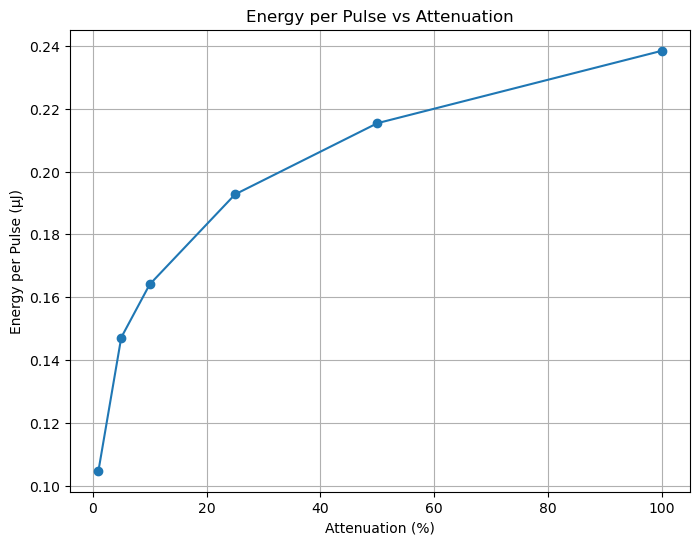

In [78]:
# rate set to 15 Hz

attenuation = [1,5, 10, 25, 50, 100] #pct
mean_power = [1.571, 2.207, 2.461, 2.891, 3.231, 3.577] #microW
std_power = [53.12, 172.4, 116.4, 229.2, 28.25, 234.2] #nanoW

energy_per_pulse = [mean_power/ ALIGN_HZ for mean_power in mean_power] #microJ

plt.figure(figsize=(8,6))
plt.plot(attenuation, energy_per_pulse, marker='o', linestyle='-')
plt.title('Energy per Pulse vs Attenuation')
plt.xlabel('Attenuation (%)')
plt.ylabel('Energy per Pulse (µJ)')
plt.grid(True)
